## Preparation for Augmenterra results (Sentinel-1)

### Inspect data

In [2]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np

In [3]:
data_dir = Path(
    "/home/lukasscharf/projects/ADUCAT/data/Augmenterra/ASC"
)

shapefiles = sorted(data_dir.glob("*.shp"))

print(f"Found {len(shapefiles)} shapefiles:")

for shp in shapefiles:
    print(shp.name)

Found 9 shapefiles:
AT_VIENNA_TUNNELLING_SNT_T73_A_1_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_2_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_3_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_4_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_5_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_6_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_7_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_8_ES13437A001S.shp
AT_VIENNA_TUNNELLING_SNT_T73_A_9_ES13437A001S.shp


In [4]:
# read one shapefile

shp = shapefiles[0]

gdf = gpd.read_file(shp)

print(f"File: {shp.name}")
print(f"Number of points: {len(gdf):,}")
print(f"CRS: {gdf.crs}")
print(f"Geometry types:")
print(gdf.geometry.geom_type.value_counts())


File: AT_VIENNA_TUNNELLING_SNT_T73_A_1_ES13437A001S.shp
Number of points: 19,922
CRS: EPSG:4326
Geometry types:
Point    19922
Name: count, dtype: int64


In [5]:
print("Columns:")
for i, col in enumerate(gdf.columns):
    print(f"{i:3d}: {col}")

Columns:
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: ACC
  6: A_STDEV
  7: SEASON_AMP
  8: S_AMP_STD
  9: SEASON_PHS
 10: S_PHS_STD
 11: COHERENCE
 12: STD_DEF
 13: EFF_AREA
 14: INC_ANG
 15: D20190105
 16: D20190111
 17: D20190117
 18: D20190123
 19: D20190204
 20: D20190210
 21: D20190216
 22: D20190222
 23: D20190228
 24: D20190306
 25: D20190312
 26: D20190318
 27: D20190324
 28: D20190330
 29: D20190405
 30: D20190411
 31: D20190417
 32: D20190423
 33: D20190429
 34: D20190505
 35: D20190511
 36: D20190517
 37: D20190523
 38: D20190529
 39: D20190604
 40: D20190610
 41: D20190616
 42: D20190622
 43: D20190628
 44: D20190704
 45: D20190710
 46: D20190716
 47: D20190722
 48: D20190728
 49: D20190803
 50: D20190809
 51: D20190815
 52: D20190821
 53: D20190827
 54: D20190902
 55: D20190908
 56: D20190914
 57: D20190920
 58: D20190926
 59: D20191002
 60: D20191008
 61: D20191014
 62: D20191020
 63: D20191026
 64: D20191101
 65: D20191107
 66: D20191113
 67: D20191119


In [6]:
gdf.dtypes

CODE              str
HEIGHT        float64
H_STDEV       float64
VEL           float64
V_STDEV       float64
               ...   
D20260416     float64
D20260417     float64
D20260422     float64
D20260428     float64
geometry     geometry
Length: 359, dtype: object

In [7]:
gdf.head(1).T

,0
CODE,CW0WJE401
HEIGHT,226.5
H_STDEV,2.5
VEL,-0.4
V_STDEV,0.2
...,...
D20260416,-1.7
D20260417,-2.4
D20260422,-14.7
D20260428,3.8


In [8]:
gdf.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODE,19922,19922,CW0WJE401,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HEIGHT,19922.0,NaN,NaN,NaN,200.90127,8.244164,180.0,194.8,200.2,206.5,250.4
H_STDEV,19922.0,NaN,NaN,NaN,2.281498,0.301315,1.3,2.1,2.4,2.5,3.1
VEL,19922.0,NaN,NaN,NaN,-0.390066,1.321711,-5.0,-1.1,-0.3,0.4,3.0
V_STDEV,19922.0,NaN,NaN,NaN,0.186738,0.033917,0.1,0.2,0.2,0.2,0.2
...,...,...,...,...,...,...,...,...,...,...,...
D20260416,19922.0,NaN,NaN,NaN,-3.412037,12.407479,-61.6,-11.0,-2.5,4.5,39.6
D20260417,19922.0,NaN,NaN,NaN,-3.077798,12.450393,-57.7,-10.5,-2.2,4.8,44.4
D20260422,19922.0,NaN,NaN,NaN,-3.045959,12.594168,-59.0,-10.9,-2.3,5.2,47.9
D20260428,19922.0,NaN,NaN,NaN,-2.947274,12.479594,-57.2,-10.8,-2.1,5.3,40.2


In [9]:
# CRS
print("CRS name:", gdf.crs.name)
print("EPSG:", gdf.crs.to_epsg())

CRS name: WGS 84
EPSG: 4326


### Recalculate Velocities

In [8]:
print(gdf.head())

        CODE  HEIGHT  H_STDEV  VEL  V_STDEV  ACC  A_STDEV  SEASON_AMP  \
0  CW0WJE401   226.5      2.5 -0.4      0.2  0.0      0.2        0.78   
1  CW1HYZW01   212.4      2.4  0.2      0.2  0.1      0.2        1.59   
2  CW23ELO01   216.1      2.5  0.1      0.2 -0.0      0.2        0.69   
3  CVKTU2501   223.8      2.5 -0.9      0.2 -0.2      0.2        0.75   
4  CVN7KH901   220.8      2.6 -0.0      0.2 -0.1      0.2        1.01   

   S_AMP_STD  SEASON_PHS  ...  D20260323  D20260329  D20260404  D20260410  \
0       0.63       -4.45  ...      -15.6       11.5       -0.6      -10.8   
1       0.58      -39.67  ...       14.0       14.8        3.0       -8.3   
2       0.62      -73.30  ...        8.0       12.5        0.8      -11.1   
3       0.62       -9.61  ...        2.7       -4.3      -10.5       -6.3   
4       0.63     -126.02  ...        5.1        4.6        3.9       -3.7   

   D20260416  D20260417  D20260422  D20260428                   geometry  \
0       -1.7       -2.

In [ ]:
import re

# Find all time-series columns
ts_cols = [
    c for c in gdf.columns
    if re.fullmatch(r"D\d{8}", c)
]

# Extract dates from column names
dates = pd.to_datetime(
    [c[1:] for c in ts_cols],
    format="%Y%m%d"
)

# Convert dates to elapsed years
t = (
    dates - dates[0]
).total_seconds() / (365.25 * 24 * 3600)

# Convert displacement values to numeric
Y = gdf[ts_cols].apply(
    pd.to_numeric,
    errors="coerce"
).to_numpy()

# Calculate linear velocity for every point
velocities = np.full(len(gdf), np.nan)

for i in range(len(gdf)):
    y = Y[i]
    valid = np.isfinite(y)

    if valid.sum() >= 2:
        velocities[i] = np.polyfit(
            t[valid],
            y[valid],
            1
        )[0]

# Add calculated velocity
gdf["VEL_CALC"] = velocities.round(1)

print(f"Time series: {dates.min().date()} → {dates.max().date()}")
print(f"Observations: {len(dates)}")

Time series: 2019-01-05 → 2026-04-28
Observations: 343


In [11]:
comparison = gdf[["CODE", "VEL", "VEL_CALC"]].copy()

comparison["DIFF"] = (
    comparison["VEL_CALC"] - comparison["VEL"]
)

print(comparison.head(20))

print("\nStatistics:")
print(comparison[["VEL", "VEL_CALC", "DIFF"]].describe())

         CODE  VEL  VEL_CALC  DIFF
0   CW0WJE401 -0.4      -0.4   0.0
1   CW1HYZW01  0.2       0.2   0.0
2   CW23ELO01  0.1       0.1   0.0
3   CVKTU2501 -0.9      -0.9   0.0
4   CVN7KH901 -0.0      -0.0   0.0
5   CVUCRQL01 -4.5      -4.5   0.0
6   CWX1Y2101 -0.9      -0.9   0.0
7   CWMXKRU01 -0.9      -0.9   0.0
8   CWFSDIK01 -0.9      -0.9   0.0
9   CWE02P901 -1.5      -1.5   0.0
10  CWELIB101 -1.3      -1.3   0.0
11  D00E06F01  0.5       0.5   0.0
12  D00ZFS701 -0.6      -0.6   0.0
13  CZZ74YW01 -0.7      -0.7   0.0
14  CZZSKKO01 -0.3      -0.3   0.0
15  D00E06G01  0.8       0.8   0.0
16  D03YLT501 -0.3      -0.3   0.0
17  D06XRU101 -0.3      -0.3   0.0
18  D09BI9501 -4.8      -4.8   0.0
19  D04K1EY01 -0.5      -0.5   0.0

Statistics:
                VEL      VEL_CALC          DIFF
count  19922.000000  19922.000000  19922.000000
mean      -0.390066     -0.390302     -0.000236
std        1.321711      1.322564      0.009208
min       -5.000000     -5.100000     -0.100000
25%       -1

In [15]:
print(dates)
print(ts_cols)

DatetimeIndex(['2019-01-05', '2019-01-11', '2019-01-17', '2019-01-23',
               '2019-02-04', '2019-02-10', '2019-02-16', '2019-02-22',
               '2019-02-28', '2019-03-06',
               ...
               '2026-03-11', '2026-03-17', '2026-03-23', '2026-03-29',
               '2026-04-04', '2026-04-10', '2026-04-16', '2026-04-17',
               '2026-04-22', '2026-04-28'],
              dtype='datetime64[us]', length=343, freq=None)
['D20190105', 'D20190111', 'D20190117', 'D20190123', 'D20190204', 'D20190210', 'D20190216', 'D20190222', 'D20190228', 'D20190306', 'D20190312', 'D20190318', 'D20190324', 'D20190330', 'D20190405', 'D20190411', 'D20190417', 'D20190423', 'D20190429', 'D20190505', 'D20190511', 'D20190517', 'D20190523', 'D20190529', 'D20190604', 'D20190610', 'D20190616', 'D20190622', 'D20190628', 'D20190704', 'D20190710', 'D20190716', 'D20190722', 'D20190728', 'D20190803', 'D20190809', 'D20190815', 'D20190821', 'D20190827', 'D20190902', 'D20190908', 'D20190914', 'D

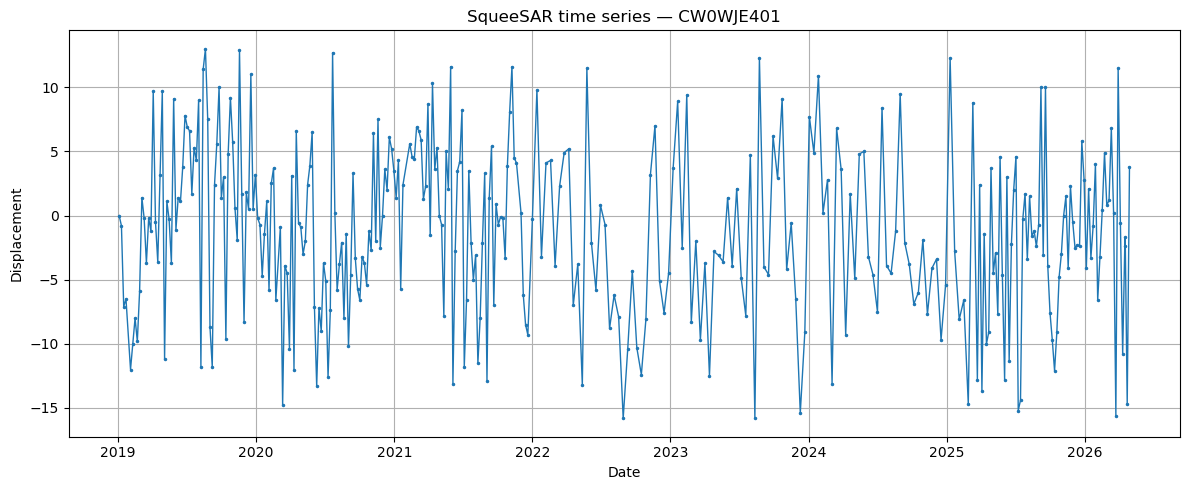

CODE         CW0WJE401
VEL               -0.4
V_STDEV            0.2
COHERENCE          0.3
ACC                0.0
A_STDEV            0.2
Name: 0, dtype: object


In [13]:
import matplotlib.pyplot as plt

code = "CW0WJE401"

point = gdf[gdf["CODE"] == code].iloc[0]

values = pd.to_numeric(
    point[ts_cols],
    errors="coerce"
)

plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    values,
    marker=".",
    markersize=3,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Displacement")
plt.title(f"SqueeSAR time series — {code}")
plt.grid(True)

plt.tight_layout()
plt.show()

print(point[["CODE", "VEL", "V_STDEV", "COHERENCE", "ACC", "A_STDEV"]])